In [1]:
import tensorflow as tf
from tensorflow.keras import models, callbacks
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
import pandas as pd

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train.astype("float32")/255.0, x_test.astype("float32")/255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [3]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))\
            .shuffle(10000).batch(128).prefetch(tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((x_test, y_test))\
            .batch(128).prefetch(tf.data.AUTOTUNE)

In [23]:
train_ds.element_spec

(TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 1), dtype=tf.uint8, name=None))

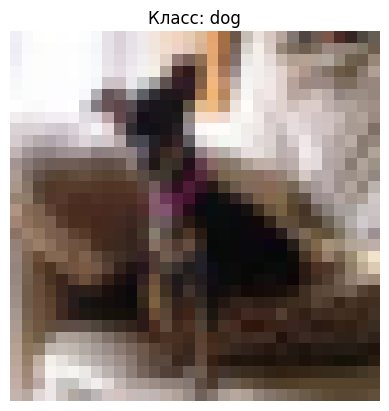

In [29]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Берём один случайный батч и выбираем первое изображение
for images, labels in test_ds.shuffle(1000).take(1):
    # Выбираем первое изображение из батча
    img = images[0].numpy()  # преобразуем в numpy
    label = int(labels[0])   # получаем метку

    plt.imshow(img)
    plt.title(f"Класс: {class_names[label]}")
    plt.axis('off')
    plt.show()

In [6]:
for batch in train_ds.take(1):  # берем первый батч
    images, labels = batch
    print("Размерность изображений:", images.shape)
    print("Размерность меток:", labels.shape)
print(train_ds.element_spec)

Размерность изображений: (128, 32, 32, 3)
Размерность меток: (128, 1)
(TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.uint8, name=None))


In [7]:
model = Sequential([
    Conv2D(32, 3, activation='relu', padding='same', input_shape=(32,32,3)),
    MaxPooling2D(2),
    Conv2D(64, 3, activation='relu', padding='same'),
    MaxPooling2D(2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
cb = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint('week2-day10-cifar10.h5', save_best_only=True),
    callbacks.TensorBoard(log_dir='week2-day10-logs')
]

In [10]:
model.fit(train_ds, epochs=20, validation_data=test_ds, callbacks=cb)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3450 - loss: 1.7975

391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3452 - loss: 1.7969 - val_accuracy: 0.5496 - val_loss: 1.2667
Epoch 2/20
387/391 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5474 - loss: 1.2683

391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5477 - loss: 1.2678 - val_accuracy: 0.6169 - val_loss: 1.1001
Epoch 3/20
384/391 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6081 - loss: 1.1061

391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6083 - loss: 1.1056 - val_accuracy: 0.6605 - val_loss: 0.9759
Epoch 4/20
385/391 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6428 - loss: 1.0063

391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6429 - loss: 1.0061 - val_accuracy: 0.6598 - val_loss: 0.9480
Epoch 5/20
385/391 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6684 - loss: 0.9382

...

391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7121 - loss: 0.8248 - val_accuracy: 0.7054 - val_loss: 0.8478
Epoch 8/20
385/391 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7261 - loss: 0.7763

391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7262 - loss: 0.7762 - val_accuracy: 0.7087 - val_loss: 0.8358
Epoch 9/20
385/391 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7399 - loss: 0.7270

391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7399 - loss: 0.7271 - val_accuracy: 0.7230 - val_loss: 0.8046
Epoch 10/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7563 - loss: 0.6898 - val_accuracy: 0.7148 - val_loss: 0.8218
Epoch 11/20
389/391 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7654 - loss: 0.6601

391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7654 - loss: 0.6601 - val_accuracy: 0.7212 - val_loss: 0.8031
Epoch 12/20
388/391 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7841 - loss: 0.6113

391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7841 - loss: 0.6114 - val_accuracy: 0.7287 - val_loss: 0.7968
Epoch 13/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7871 - loss: 0.5910 - val_accuracy: 0.7294 - val_loss: 0.7968
Epoch 14/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7965 - loss: 0.5677 - val_accuracy: 0.7266 - val_loss: 0.8343
Epoch 15/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8076 - loss: 0.5370 - val_accuracy: 0.7301 - val_loss: 0.8226
Epoch 16/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8162 - loss: 0.5073 - val_accuracy: 0.7308 - val_loss: 0.8302
Epoch 17/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8287 - loss: 0.4818 - val_accuracy: 0.7288 - val_loss: 0.8362


In [11]:
pred = model.predict(test_ds)

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [12]:
pred

array([[4.89335507e-03, 7.74089899e-03, 1.19239220e-03, ...,
        1.83914194e-03, 1.28066484e-02, 1.16336893e-03],
       [1.12532685e-03, 5.38945086e-02, 2.09549825e-07, ...,
        5.19664589e-11, 9.44819272e-01, 1.59998381e-04],
       [5.81002653e-01, 6.80853575e-02, 1.71468116e-03, ...,
        6.76891534e-04, 3.26634914e-01, 1.72719993e-02],
       ...,
       [2.26997236e-05, 3.81759193e-08, 3.32162622e-03, ...,
        1.46061135e-02, 1.04581122e-05, 1.24202516e-05],
       [3.81675422e-01, 3.22119862e-01, 2.38408409e-02, ...,
        1.19682685e-04, 5.39010907e-05, 2.93402321e-04],
       [1.70085445e-06, 7.56589429e-07, 3.14486981e-03, ...,
        9.48355258e-01, 9.08959450e-08, 3.92764150e-06]], dtype=float32)

In [13]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7296 - loss: 0.7868
Test Accuracy: 72.87%


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


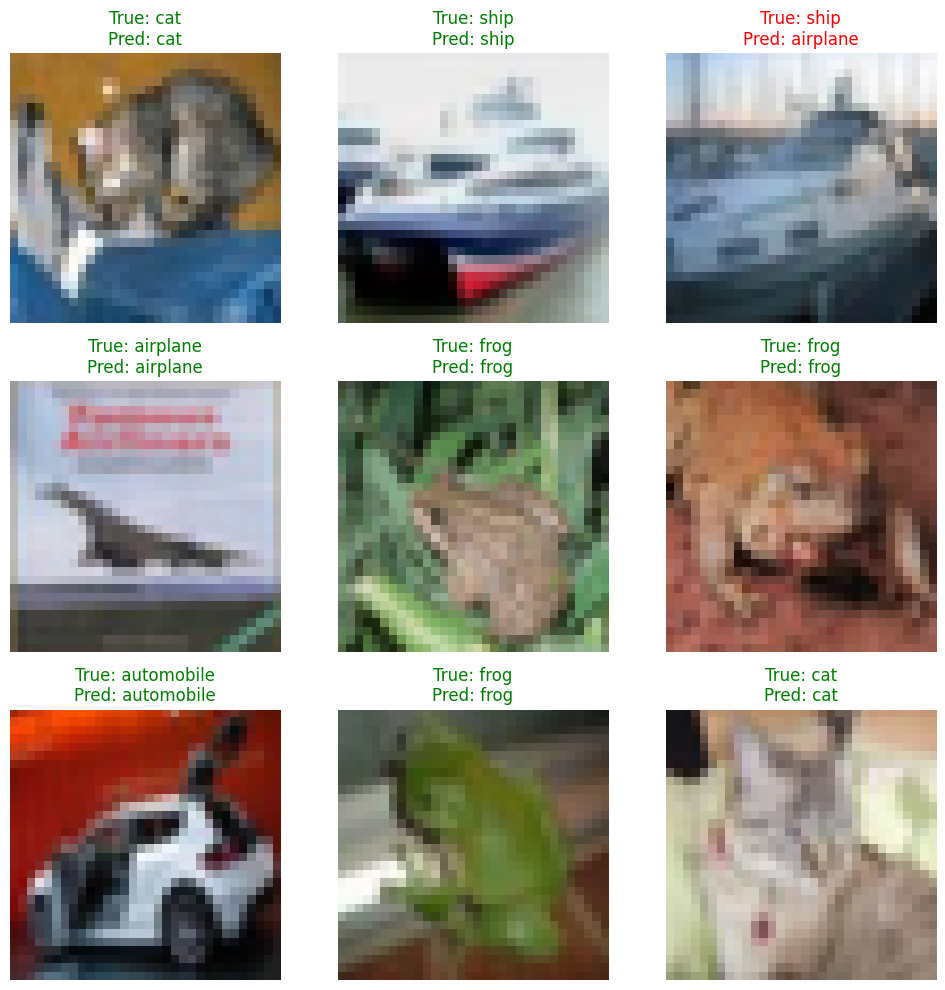

In [20]:
import matplotlib.pyplot as plt

# Классы CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

for images, labels in test_ds.take(1):
    preds = model.predict(images)
    preds_classes = tf.argmax(preds, axis=1)

    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])

        true_label = class_names[int(labels[i])]
        pred_label = class_names[preds_classes[i]]


        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()